**Install & Import Required Libraries**

In [2]:
!pip install kaggle torch torchvision timm scikit-learn matplotlib pandas

import os
import zipfile
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

import timm   # for EfficientNetV2 & Vision Transformer


**Download Dataset from Kaggle**

In [3]:
# Upload kaggle.json (from your Kaggle account > Account > Create API Token)
from google.colab import files
files.upload()   # upload kaggle.json

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download CBIS-DDSM dataset
!kaggle datasets download -d awsaf49/cbis-ddsm-breast-cancer-image-dataset

# Unzip dataset
!unzip -q cbis-ddsm-breast-cancer-image-dataset.zip -d cbis_ddsm


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset
License(s): CC-BY-SA-3.0
100% 4.93G/4.95G [01:44<00:00, 116MB/s] 
100% 4.95G/4.95G [01:44<00:00, 50.7MB/s]


**Load Metadata & Combine CSVs**

In [4]:
# Load all CSVs
mass_train = pd.read_csv("/content/cbis_ddsm/csv/mass_case_description_train_set.csv")
mass_test  = pd.read_csv("/content/cbis_ddsm/csv/mass_case_description_test_set.csv")
calc_train = pd.read_csv("/content/cbis_ddsm/csv/calc_case_description_train_set.csv")
calc_test  = pd.read_csv("/content/cbis_ddsm/csv/calc_case_description_test_set.csv")

# Combine into one dataframe
meta = pd.concat([mass_train, mass_test, calc_train, calc_test], axis=0)

# Keep only benign & malignant
meta = meta[meta['pathology'].isin(['BENIGN', 'MALIGNANT'])].copy()

# Map labels → 0 = BENIGN, 1 = MALIGNANT
meta['label'] = meta['pathology'].map({'BENIGN': 0, 'MALIGNANT': 1})

print("Total metadata cases:", len(meta))
print(meta[['patient_id','pathology','cropped image file path']].head())


Total metadata cases: 2886
  patient_id  pathology                            cropped image file path
0    P_00001  MALIGNANT  Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1    P_00001  MALIGNANT  Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2    P_00004     BENIGN  Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...
3    P_00004     BENIGN  Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...
4    P_00004     BENIGN  Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....


**Link Metadata with JPEG Files**

In [5]:
import glob

# 1. Collect all JPEG image paths
all_images = glob.glob("/content/cbis_ddsm/jpeg/**/*.jpg", recursive=True)
print("Total JPEG images found:", len(all_images))

# 2. Build dataframe from JPEGs
df = pd.DataFrame(all_images, columns=["image_path"])

# Extract UID = parent folder name (example: 1.3.6.1.4.1.9590...)
df["uid"] = df["image_path"].apply(lambda x: x.split("/")[-2])

# 3. Extract UID from metadata
meta["uid"] = meta["cropped image file path"].apply(lambda x: x.split("/")[2])

# 4. Merge metadata + JPEGs on UID
df = df.merge(meta[["uid", "label"]], on="uid", how="inner")

print("After merging:", len(df), "samples")
print(df.head())


Total JPEG images found: 10237
After merging: 5673 samples
                                          image_path  \
0  /content/cbis_ddsm/jpeg/1.3.6.1.4.1.9590.100.1...   
1  /content/cbis_ddsm/jpeg/1.3.6.1.4.1.9590.100.1...   
2  /content/cbis_ddsm/jpeg/1.3.6.1.4.1.9590.100.1...   
3  /content/cbis_ddsm/jpeg/1.3.6.1.4.1.9590.100.1...   
4  /content/cbis_ddsm/jpeg/1.3.6.1.4.1.9590.100.1...   

                                                 uid  label  
0  1.3.6.1.4.1.9590.100.1.2.106588546212208683524...      1  
1  1.3.6.1.4.1.9590.100.1.2.106588546212208683524...      1  
2  1.3.6.1.4.1.9590.100.1.2.374467146111101869235...      0  
3  1.3.6.1.4.1.9590.100.1.2.374467146111101869235...      0  
4  1.3.6.1.4.1.9590.100.1.2.155107802112769556437...      0  


**Train/Validation Split**

In [6]:
# Split 80% train / 20% validation
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],   # ensures equal class distribution
    random_state=42
)

print("Total samples:", len(df))
print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Class distribution (train):\n", train_df['label'].value_counts())
print("Class distribution (val):\n", val_df['label'].value_counts())


Total samples: 5673
Train samples: 4538
Validation samples: 1135
Class distribution (train):
 label
1    2314
0    2224
Name: count, dtype: int64
Class distribution (val):
 label
1    579
0    556
Name: count, dtype: int64


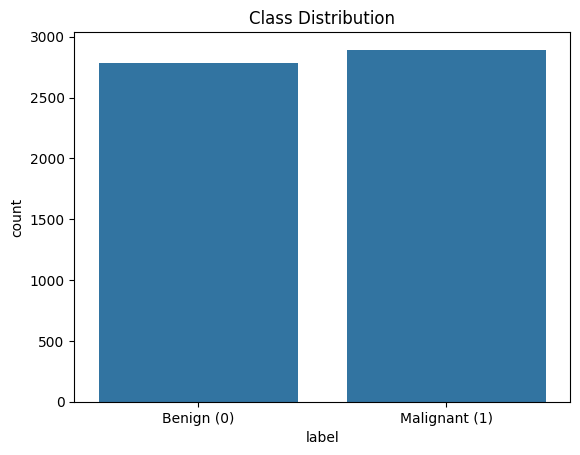

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot class distribution
sns.countplot(data=df, x="label")
plt.xticks([0,1], ["Benign (0)", "Malignant (1)"])
plt.title("Class Distribution")
plt.show()


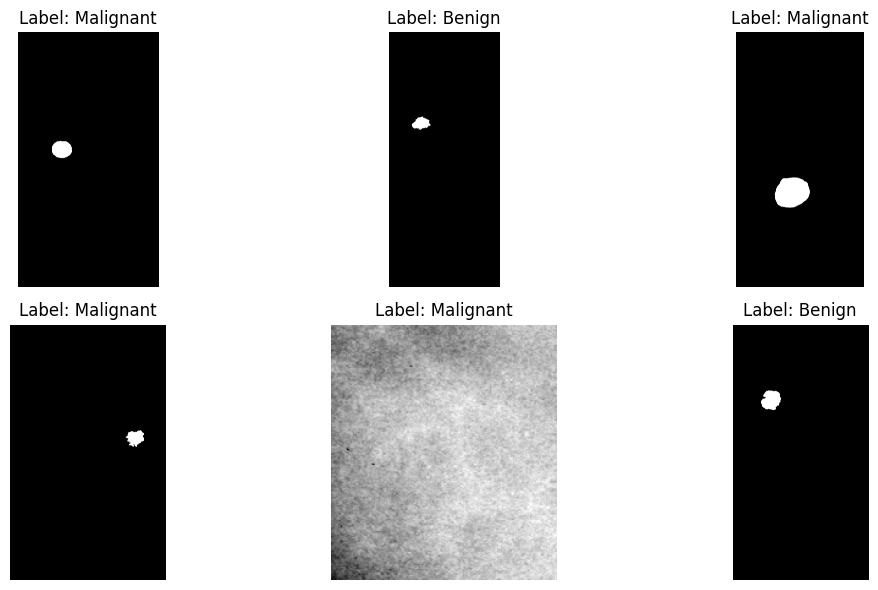

In [8]:
import random
from PIL import Image

# Pick random 6 samples
samples = train_df.sample(6).reset_index(drop=True)

plt.figure(figsize=(12,6))
for i, row in samples.iterrows():
    img = Image.open(row['image_path'])
    plt.subplot(2,3,i+1)
    plt.imshow(img, cmap="gray")
    plt.title("Label: " + ("Benign" if row['label']==0 else "Malignant"))
    plt.axis("off")
plt.tight_layout()
plt.show()


**Dataset Class + Transforms**

In [9]:
# Define image transformations (resize + normalize like ImageNet)
transform = transforms.Compose([
    transforms.Resize((224,224)),    # resize all images to 224x224
    transforms.ToTensor(),           # convert to PyTorch tensor
    transforms.Normalize(            # normalize using ImageNet stats
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Custom dataset class
class BreastCancerDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'image_path']
        label = int(self.df.loc[idx, 'label'])

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"⚠️ Error reading {img_path}: {e}")
            # Fallback: black image
            image = Image.new("RGB", (224,224))

        if self.transform:
            image = self.transform(image)

        return image, label


**Create DataLoaders**

In [10]:
train_dataset = BreastCancerDataset(train_df, transform=transform)
val_dataset   = BreastCancerDataset(val_df, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Sanity check: load one batch
images, labels = next(iter(train_loader))
print("Batch image tensor shape:", images.shape)  # [batch, channels, H, W]
print("Batch labels:", labels[:10])


Batch image tensor shape: torch.Size([32, 3, 224, 224])
Batch labels: tensor([1, 1, 1, 0, 1, 0, 1, 1, 1, 1])


**Define Models (ResNet50, EfficientNetV2, Vision Transformer)**

In [11]:
def get_model(model_name="resnet50", num_classes=2):
    if model_name == "resnet50":
        # Load pretrained ResNet50
        model = models.resnet50(pretrained=True)
        # Replace last FC layer with our 2-class output
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == "efficientnet_v2":
        # EfficientNetV2 from timm
        model = timm.create_model("efficientnetv2_s", pretrained=True, num_classes=num_classes)

    elif model_name == "vit":
        # Vision Transformer from timm
        model = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=num_classes)

    else:
        raise ValueError("Unknown model! Use 'resnet50', 'efficientnet_v2', or 'vit'")

    return model

# Pick device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Example: initialize ResNet50
model = get_model("resnet50", num_classes=2).to(device)
print(model)


Using device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 205MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

**Training Loop with Metrics (With Loss Function)**

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# =========================
# LOSS FUNCTION
# =========================
# CrossEntropyLoss is standard for multi-class or binary classification
# It combines LogSoftmax + Negative Log-Likelihood
criterion = nn.CrossEntropyLoss()

# =========================
# OPTIMIZER
# =========================
# Adam optimizer with weight decay to prevent overfitting
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

# =========================
# LEARNING RATE SCHEDULER
# =========================
# Reduce learning rate when validation loss plateaus
from torch.optim.lr_scheduler import ReduceLROnPlateau
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

# =========================
# METRICS FUNCTION
# =========================
def calc_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return acc, prec, rec, f1

# =========================
# TRAINING FUNCTION
# =========================
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=5, device="cpu"):
    history = {"train_loss": [], "val_loss": [],
               "train_acc": [], "val_acc": [],
               "train_prec": [], "val_prec": [],
               "train_rec": [], "val_rec": [],
               "train_f1": [], "val_f1": []}

    best_val_f1 = 0.0  # to save best model

    for epoch in range(epochs):
        # ---- Training ----
        model.train()
        train_loss, all_preds, all_labels = 0.0, [], []
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            # =========================
            # LOSS CALCULATION
            # =========================
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        train_loss /= len(train_loader.dataset)
        train_acc, train_prec, train_rec, train_f1 = calc_metrics(all_labels, all_preds)

        # ---- Validation ----
        model.eval()
        val_loss, all_preds, all_labels = 0.0, [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_acc, val_prec, val_rec, val_f1 = calc_metrics(all_labels, all_preds)

        # Save history
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_prec"].append(train_prec)
        history["val_prec"].append(val_prec)
        history["train_rec"].append(train_rec)
        history["val_rec"].append(val_rec)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)

        # Step scheduler with validation loss
        scheduler.step(val_loss)

        # Save best model (based on validation F1-score)
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), "best_model.pth")
            print("✅ Best model saved (F1 improved).")

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f} Val Loss: {val_loss:.4f} "
              f"Train Acc: {train_acc:.4f} Val Acc: {val_acc:.4f} "
              f"Val F1: {val_f1:.4f}")

    return model, history


**Focal Loss**

In [13]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        BCE_loss = nn.CrossEntropyLoss(reduction='none')(inputs, targets)
        pt = torch.exp(-BCE_loss)
        focal_loss = self.alpha * (1-pt)**self.gamma * BCE_loss
        return focal_loss.mean()


**Run Training**

In [14]:
# Run training (example: 10 epochs)
model, history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,   # ✅ adding scheduler here
    epochs=10,
    device=device
)


✅ Best model saved (F1 improved).
Epoch [1/10] Train Loss: 0.6784 Val Loss: 0.6809 Train Acc: 0.5884 Val Acc: 0.5859 Val F1: 0.4902
✅ Best model saved (F1 improved).
Epoch [2/10] Train Loss: 0.6376 Val Loss: 0.6631 Train Acc: 0.6349 Val Acc: 0.6088 Val F1: 0.6085
✅ Best model saved (F1 improved).
Epoch [3/10] Train Loss: 0.5861 Val Loss: 0.6305 Train Acc: 0.6822 Val Acc: 0.6546 Val F1: 0.6260
✅ Best model saved (F1 improved).
Epoch [4/10] Train Loss: 0.5423 Val Loss: 0.6301 Train Acc: 0.7140 Val Acc: 0.6203 Val F1: 0.6677
Epoch [5/10] Train Loss: 0.4634 Val Loss: 0.7870 Train Acc: 0.7662 Val Acc: 0.6599 Val F1: 0.6655
Epoch [6/10] Train Loss: 0.3889 Val Loss: 0.7663 Train Acc: 0.8109 Val Acc: 0.6317 Val F1: 0.6288
Epoch [7/10] Train Loss: 0.3277 Val Loss: 0.7968 Train Acc: 0.8409 Val Acc: 0.6493 Val F1: 0.6210
Epoch [8/10] Train Loss: 0.2589 Val Loss: 0.9620 Train Acc: 0.8905 Val Acc: 0.6335 Val F1: 0.6357
Epoch [9/10] Train Loss: 0.1359 Val Loss: 0.9618 Train Acc: 0.9520 Val Acc: 0.64

**Plot Training & Validation Curves**

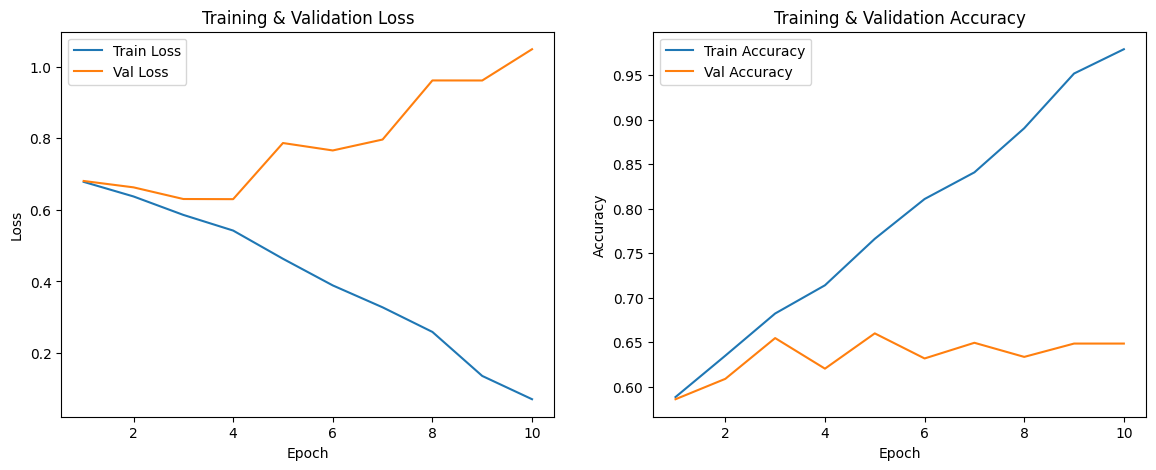

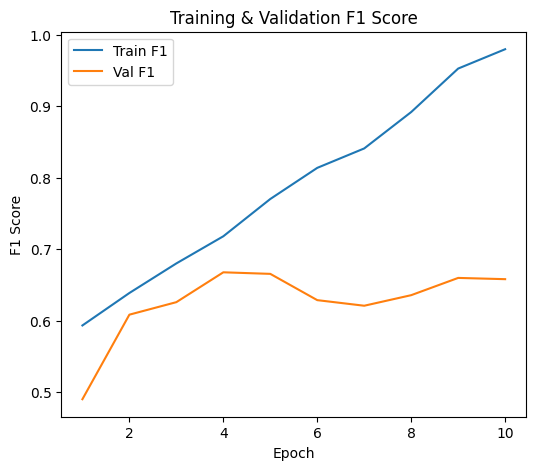

In [15]:
def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(14,5))

    # ---- Loss ----
    plt.subplot(1,2,1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss")
    plt.legend()

    # ---- Accuracy ----
    plt.subplot(1,2,2)
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training & Validation Accuracy")
    plt.legend()

    plt.show()

    # ---- Optional: Plot F1 Score ----
    plt.figure(figsize=(6,5))
    plt.plot(epochs, history["train_f1"], label="Train F1")
    plt.plot(epochs, history["val_f1"], label="Val F1")
    plt.xlabel("Epoch")
    plt.ylabel("F1 Score")
    plt.title("Training & Validation F1 Score")
    plt.legend()
    plt.show()

# Call after training
plot_history(history)


**Final Evaluation**

✅ Final Evaluation on Validation Set
Accuracy:  0.6485
Precision: 0.6531
Recall:    0.6632
F1 Score:  0.6581

Classification Report:
              precision    recall  f1-score   support

      Benign       0.64      0.63      0.64       556
   Malignant       0.65      0.66      0.66       579

    accuracy                           0.65      1135
   macro avg       0.65      0.65      0.65      1135
weighted avg       0.65      0.65      0.65      1135



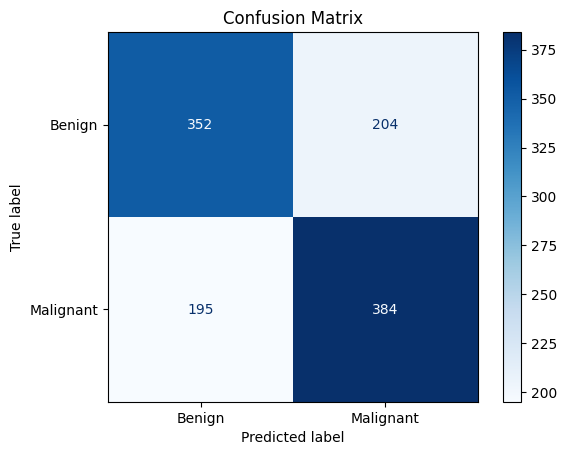

In [16]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

def evaluate_model(model, val_loader, device="cpu"):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Metrics
    acc, prec, rec, f1 = calc_metrics(all_labels, all_preds)
    print("✅ Final Evaluation on Validation Set")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=["Benign", "Malignant"]))

    # Confusion Matrix
    disp = ConfusionMatrixDisplay.from_predictions(all_labels, all_preds,
                                                   display_labels=["Benign", "Malignant"],
                                                   cmap="Blues", normalize=None)
    disp.ax_.set_title("Confusion Matrix")
    plt.show()

# Run final evaluation
evaluate_model(model, val_loader, device=device)


**Visualize Predictions**

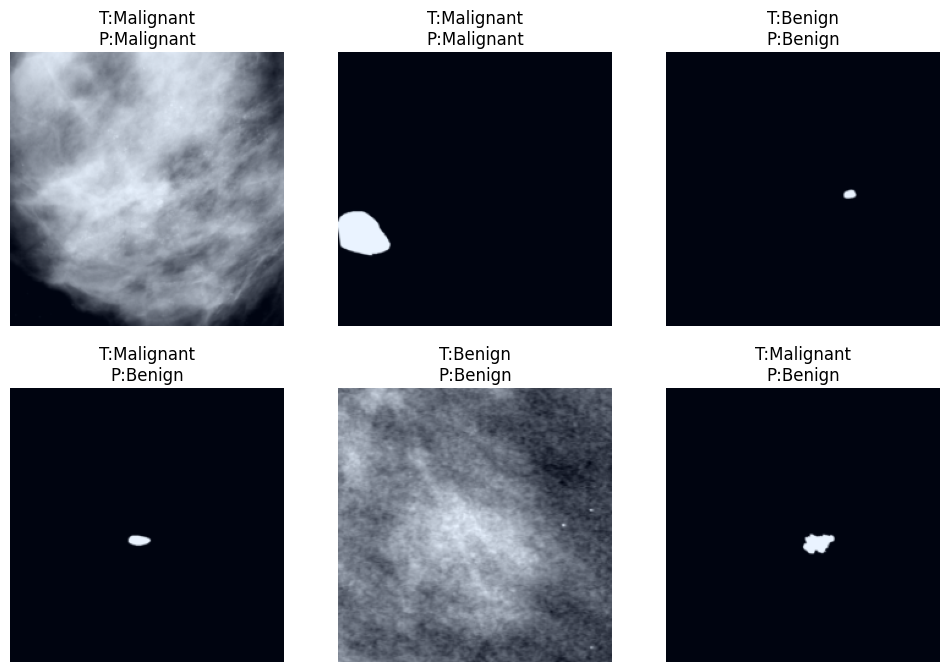

In [17]:
def visualize_predictions(model, val_loader, device="cpu", num_images=6):
    model.eval()
    images_shown = 0

    plt.figure(figsize=(12, 8))

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, 1)

            for i in range(images.size(0)):
                if images_shown >= num_images:
                    return  # stop after showing required images

                img = images[i].cpu().permute(1, 2, 0).numpy()
                img = (img - img.min()) / (img.max() - img.min())  # de-normalize to [0,1]

                true_label = "Malignant" if labels[i].item() == 1 else "Benign"
                pred_label = "Malignant" if preds[i].item() == 1 else "Benign"

                plt.subplot(2, num_images//2, images_shown + 1)
                plt.imshow(img)
                plt.axis("off")
                plt.title(f"T:{true_label}\nP:{pred_label}")

                images_shown += 1

# Show predictions
visualize_predictions(model, val_loader, device=device, num_images=6)
